In [25]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,r2_score,mean_squared_error,mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
import warnings
import pickle

In [23]:
!pip install xgboost

In [24]:
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('/content/auto-mpg.csv')

In [3]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [4]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    object 
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 30.6+ KB


In [8]:
df.replace('?',np.nan,inplace = True)

In [9]:
df['horsepower'].astype('float64')

,horsepower
0,130.0
1,165.0
2,150.0
3,150.0
4,140.0
...,...
393,86.0
394,52.0
395,84.0
396,79.0


In [10]:
df = df.dropna()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    object 
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 30.6+ KB


In [15]:
for i in df.columns:
  print((df[i]=="?").sum())

0
0
0
0
0
0
0
0
0


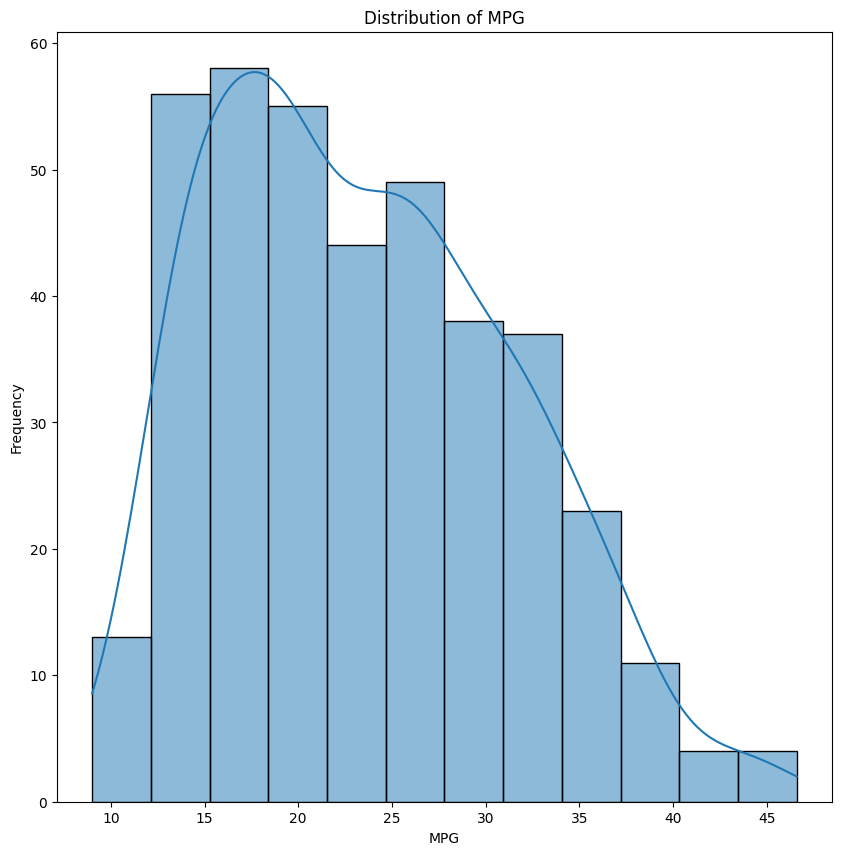

In [17]:
# EDA


plt.figure(figsize=(10,10))
sns.histplot(df['mpg'], kde = True)
plt.title('Distribution of MPG')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='weight', ylabel='mpg'>

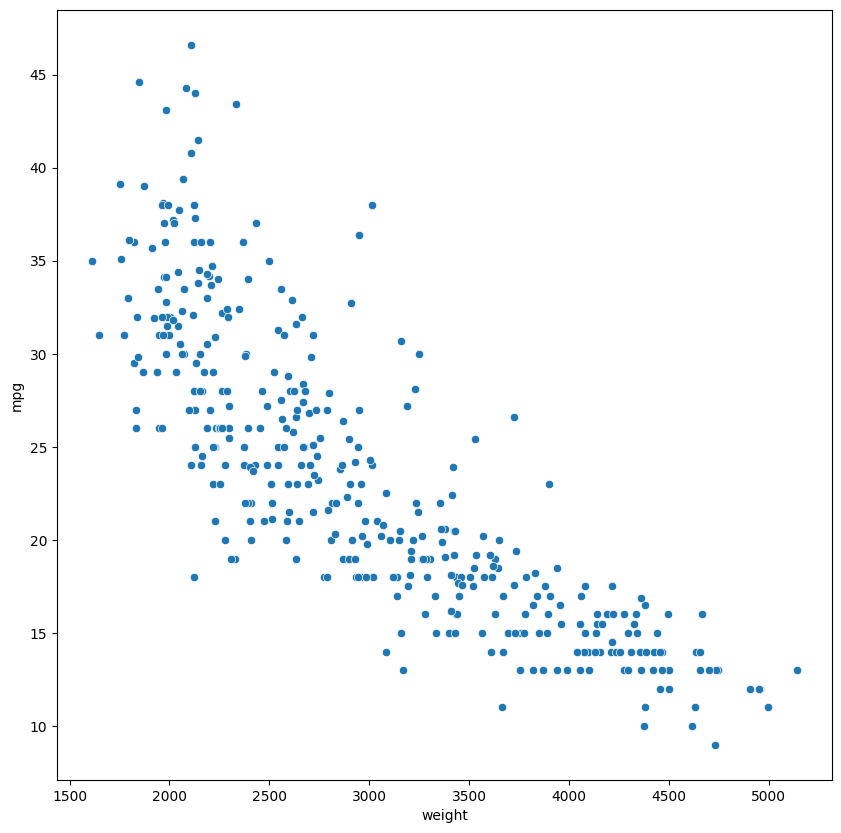

In [18]:
#Scatter plot

plt.figure(figsize=(10,10))
sns.scatterplot(x='weight',y='mpg',data=df)

In [19]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

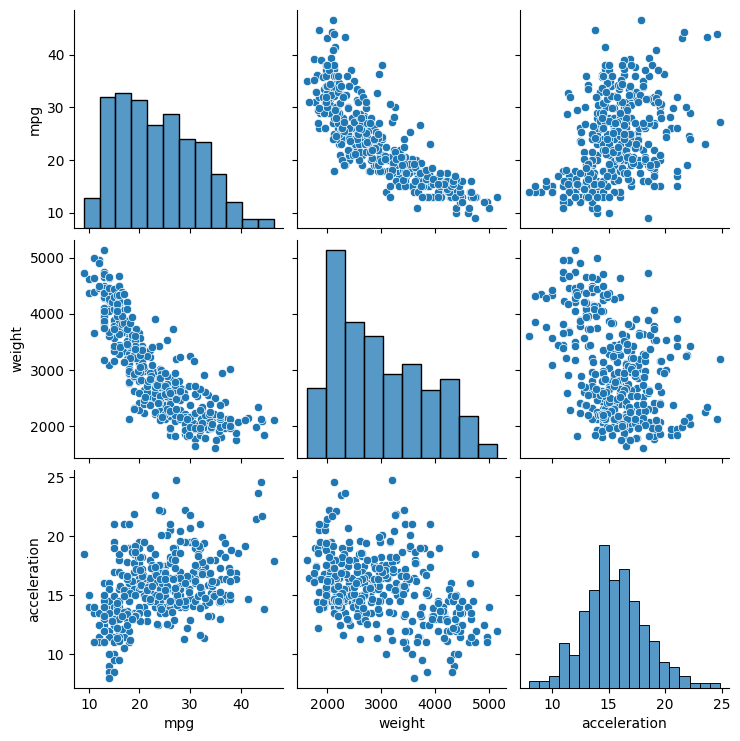

In [20]:
#Pair plot

sns.pairplot(df[["mpg","horsepower","weight","acceleration"]])
plt.show()

In [26]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df_numeric = df.select_dtypes(include=np.number)
print("Converted 'horsepower' to numeric and created 'df_numeric' with only numerical columns.")
print(df_numeric.head())

Converted 'horsepower' to numeric and created 'df_numeric' with only numerical columns.
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0         130    3504          12.0   
1  15.0          8         350.0         165    3693          11.5   
2  18.0          8         318.0         150    3436          11.0   
3  16.0          8         304.0         150    3433          12.0   
4  17.0          8         302.0         140    3449          10.5   

   model year  origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  


/tmp/ipython-input-3652395664.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')


**Reasoning**:
Now that we have successfully identified and isolated the numerical columns in `df_numeric`, the next step is to generate box plots for each of these columns to visualize potential outliers as per the task requirements.



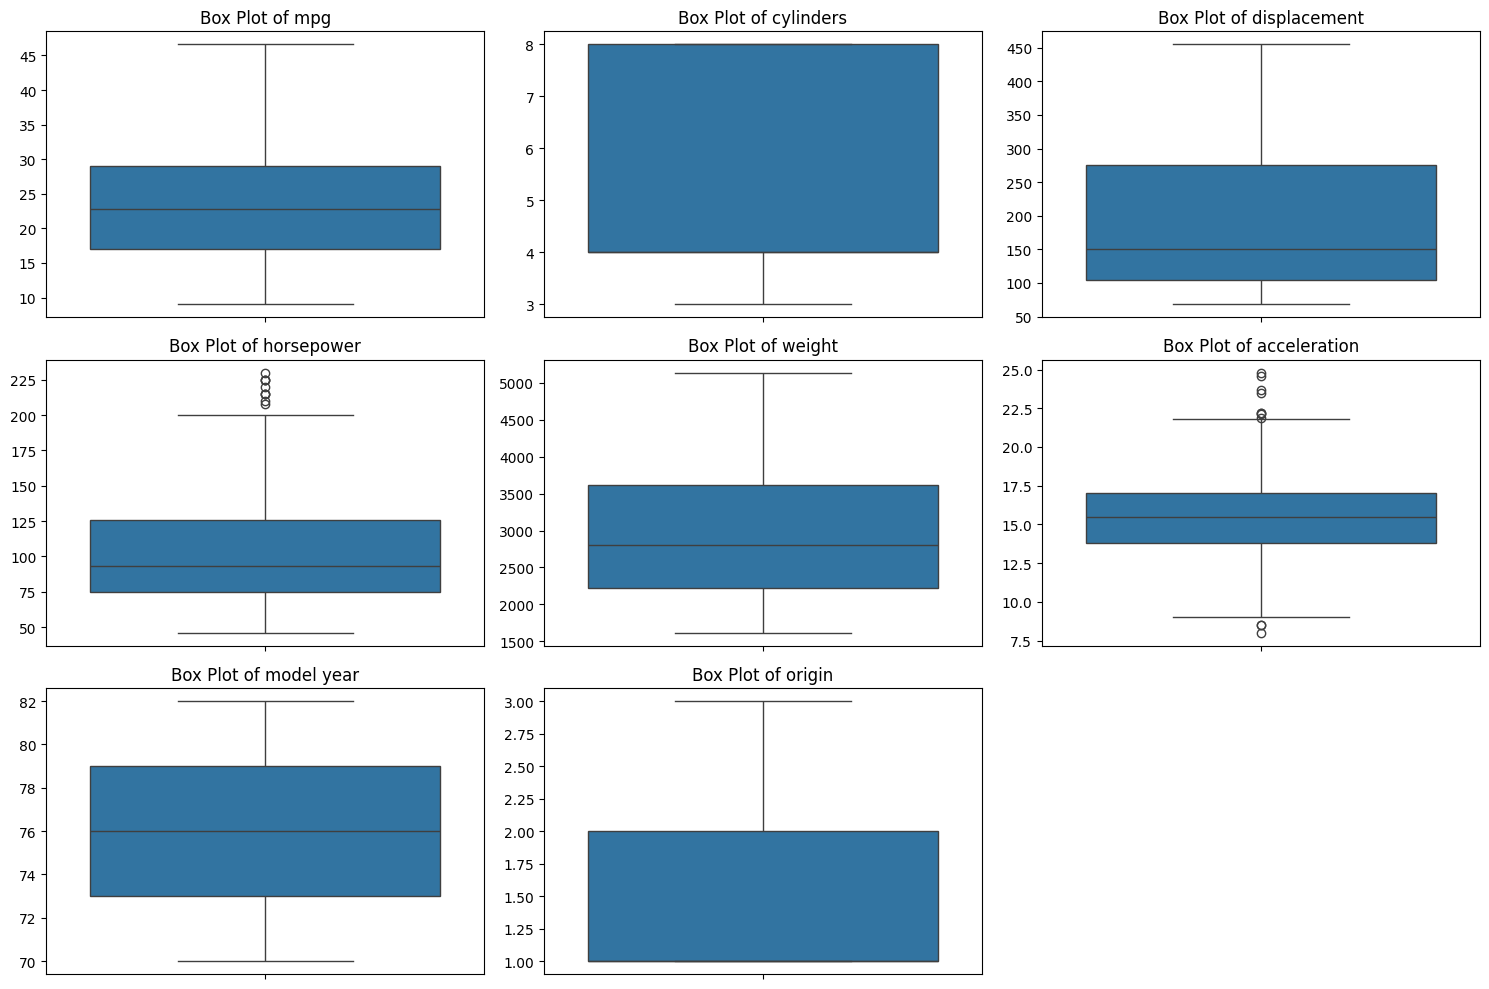

Generated box plots for all numerical columns to visualize outliers.


In [27]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(df_numeric.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.boxplot(y=df_numeric[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel('') # Clear y-label as column name is in title
plt.tight_layout()
plt.show()
print("Generated box plots for all numerical columns to visualize outliers.")

In [28]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [29]:
x = df[['cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin']]
y = df['mpg']


In [43]:
#Train test splits

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=12)

In [31]:
XGBRegressor_model = XGBRegressor(n_estimators=100,learning_rate=0.01,subsample=0.8,colsample_bytree=0.8,max_depth=3)

In [33]:
#Train the model

XGBRegressor_model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
y_pred = XGBRegressor_model.predict(x_test)

In [35]:
mean = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [38]:
print("Mean Squared Error:",mean)
print("R2 Score:",r2)

Mean Squared Error: 22.202555554465967
R2 Score: 0.6735450151329248


In [44]:
#train the model by using Linear Regression

model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [45]:
y_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)

In [47]:
print(f'Test results : {r2_score(y_test,y_pred)}')
print(f'Train results : {r2_score(y_train,y_train_pred)}')

Test results : 0.7918912906118835
Train results : 0.8271220574112091


In [48]:
import pickle
with open('Best_model.pkl','wb') as f:
  pickle.dump(model,f)